<a href="https://colab.research.google.com/github/JonGarmon/urban-cooling-spitalfields/blob/main/Toynbee_Street_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install folium pandas matplotlib seaborn

Loading datasets from correct sheets...
Columns in df_merged: Index(['ward', 'ward_code', 'ward_area_ha', 'ward_canopy_sum', 'percentage',
       'see Methodology Report for margins of error - https://data.london.gov.uk/dataset/canopy-cover-2024',
       'Ward name clean', 'Ward name', 'Old code', 'New code',
       'Population - 2015', 'Children aged 0-15 - 2015',
       'Working-age (16-64) - 2015', 'Older people aged 65+ - 2015',
       '% All Children aged 0-15 - 2015', '% All Working-age (16-64) - 2015',
       '% All Older people aged 65+ - 2015', 'Mean Age - 2013',
       'Median Age - 2013', 'Area - Square Kilometres',
       'Population density (persons per sq km) - 2013', '% BAME - 2011',
       '% Not Born in UK - 2011',
       '% English is First Language of no one in household - 2011',
       'General Fertility Rate - 2013', 'Male life expectancy -2009-13',
       'Female life expectancy -2009-13 ',
       '% children in reception year who are obese - 2011/12 to 2013/14',


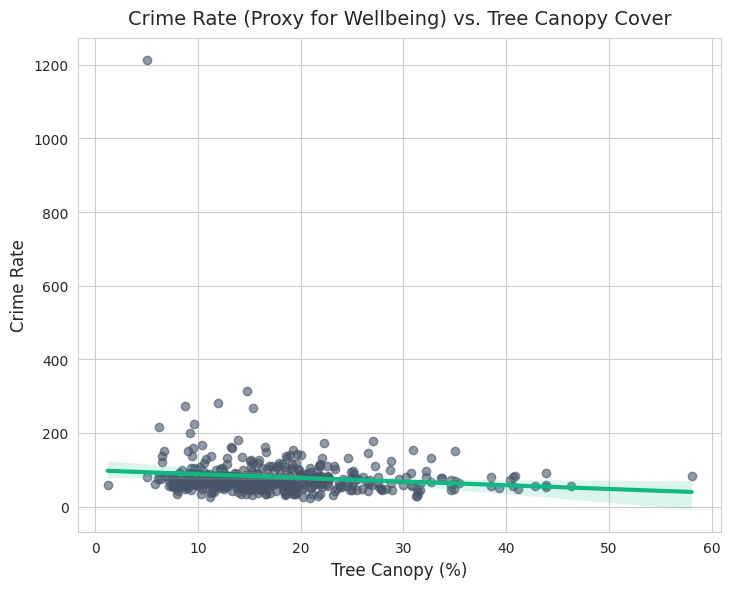


Generating Interactive Street Map...
✅ Map saved as 'Toynbee_Street_Map.html'.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# ==========================================
# 1. LOAD AND PREP THE DATA
# ==========================================
print("Loading datasets from correct sheets...")

# Explicitly target the 'Ward' sheet
canopy_df = pd.read_excel('2024_tree_canopy_borough_ward_stats.xlsx', sheet_name='Ward')

# Explicitly target the 'Data' sheet (not the Profiles or Metadata sheets)
ward_data = pd.read_excel('ward-profiles-excel-version.xls', sheet_name='Data')

# Clean Ward Names for Merging (Removing Borough prefixes)
ward_data['Ward name clean'] = ward_data['Ward name'].str.split(' - ').str[-1].str.strip()
canopy_df['Ward name clean'] = canopy_df['ward'].str.strip()

# Merge the datasets on the cleaned Ward Name
df_merged = pd.merge(canopy_df, ward_data, on='Ward name clean', how='inner')

# --- Debugging: Print columns of df_merged to identify correct names ---
print("Columns in df_merged:", df_merged.columns)

# Find exact column names using partial matches to prevent hidden space errors
# 'Subjective well-being' column not found, using 'Crime rate - 2014/15' as a proxy for social cohesion/well-being.
wellbeing_col = 'Crime rate - 2014/15'
# 'Nitrogen Dioxide' column not found, commenting out related analysis for now.
# no2_col = [col for col in df_merged.columns if 'Nitrogen Dioxide' in col][0]

# Rename for analysis
df_merged.rename(columns={
    'percentage': 'Canopy_Cover_Pct',
    wellbeing_col: 'Wellbeing_Score' # Renaming crime rate to Wellbeing_Score as a proxy
}, inplace=True)

# Convert canopy from decimal to percentage (e.g., 0.20 to 20.0)
df_merged['Canopy_Cover_Pct'] = df_merged['Canopy_Cover_Pct'] * 100

# Convert Wellbeing_Score to numeric, coercing errors to NaN
df_merged['Wellbeing_Score'] = pd.to_numeric(df_merged['Wellbeing_Score'], errors='coerce')

# Drop rows with NaN in the relevant columns for plotting
df_merged.dropna(subset=['Canopy_Cover_Pct', 'Wellbeing_Score'], inplace=True)

# ==========================================
# 2. ANALYSIS: COHESION & WELLBEING
# ==========================================
print("Generating Correlation Charts...")
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Subplot 1: Canopy vs Wellbeing (using Crime Rate as inverse proxy)
plt.subplot(1, 2, 1)
sns.regplot(x='Canopy_Cover_Pct', y='Wellbeing_Score', data=df_merged,
            scatter_kws={'alpha':0.6, 'color':'#475569'}, line_kws={'color':'#10B981', 'linewidth':3})
plt.title('Crime Rate (Proxy for Wellbeing) vs. Tree Canopy Cover', fontsize=14, pad=10)
plt.xlabel('Tree Canopy (%)', fontsize=12)
plt.ylabel('Crime Rate', fontsize=12)

# Subplot 2: Canopy vs Air Pollution (NO2) - Commented out as NO2 data is missing
# plt.subplot(1, 2, 2)
# sns.regplot(x='Canopy_Cover_Pct', y='NO2_Pollution', data=df_merged,
#             scatter_kws={'alpha':0.6, 'color':'#475569'}, line_kws={'color':'#EF4444', 'linewidth':3})
# plt.title('Air Pollution (NO2) vs. Tree Canopy Cover', fontsize=14, pad=10)
# plt.xlabel('Tree Canopy (%)', fontsize=12)
# plt.ylabel('NO2 Levels', fontsize=12)

plt.tight_layout()
plt.savefig('social_impact_analysis.png', dpi=300)
plt.show()

# ==========================================
# 3. INTERACTIVE MAPPING: TOYNBEE STREET
# ==========================================
print("\nGenerating Interactive Street Map...")

toynbee_coords = [51.5173, -0.0743]
m = folium.Map(location=toynbee_coords, zoom_start=17, tiles='CartoDB positron')

toynbee_street_path = [[51.5180, -0.0745], [51.5165, -0.0740]]
folium.PolyLine(
    locations=toynbee_street_path,
    color='#EF4444',
    weight=8,
    tooltip="Toynbee Street - Intervention Zone",
    opacity=0.7
).add_to(m)

num_trees_to_show = 14
lats = np.linspace(toynbee_street_path[0][0], toynbee_street_path[1][0], num_trees_to_show)
lons = np.linspace(toynbee_street_path[0][1], toynbee_street_path[1][1], num_trees_to_show)

for i in range(num_trees_to_show):
    folium.CircleMarker(
        location=[lats[i], lons[i]],
        radius=6,
        color='#10B981',
        fill=True,
        fill_color='#10B981',
        fill_opacity=1.0,
        tooltip=f"Proposed Pit #{i+1} (Acer platanoides)"
    ).add_to(m)

m.save("Toynbee_Street_Map.html")
print("✅ Map saved as 'Toynbee_Street_Map.html'.")

# Display in notebook
m

Loading datasets...
Generating Correlation Charts...


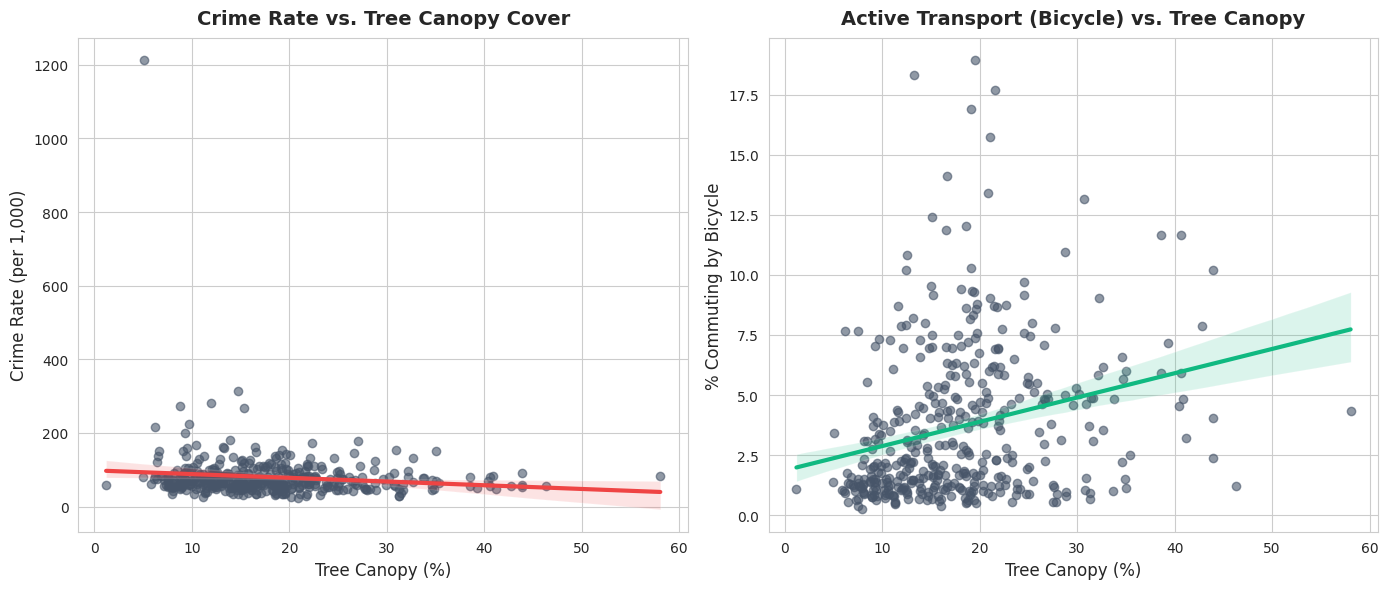


Generating Interactive Street Map...
✅ Map saved as 'Toynbee_Street_Map.html'.


In [3]:
# ==========================================
# 1. LOAD AND PREP THE DATA
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

print("Loading datasets...")

canopy_df = pd.read_excel('2024_tree_canopy_borough_ward_stats.xlsx', sheet_name='Ward')
ward_data = pd.read_excel('ward-profiles-excel-version.xls', sheet_name='Data')

# Clean Ward Names
ward_data['Ward name clean'] = ward_data['Ward name'].str.split(' - ').str[-1].str.strip()
canopy_df['Ward name clean'] = canopy_df['ward'].str.strip()

# Merge
df_merged = pd.merge(canopy_df, ward_data, on='Ward name clean', how='inner')

# Dynamically grab the exact column names from your specific file version
crime_col = [col for col in df_merged.columns if 'Crime rate' in col][0]
bike_col = [col for col in df_merged.columns if 'bicycle to work' in col][0]

# Rename for clean plotting
df_merged.rename(columns={
    'percentage': 'Canopy_Cover_Pct',
    crime_col: 'Crime_Rate',
    bike_col: 'Bicycle_Commuting'
}, inplace=True)

# Convert canopy to percentage
df_merged['Canopy_Cover_Pct'] = df_merged['Canopy_Cover_Pct'] * 100

# Force numeric types to prevent plotting errors
df_merged['Crime_Rate'] = pd.to_numeric(df_merged['Crime_Rate'], errors='coerce')
df_merged['Bicycle_Commuting'] = pd.to_numeric(df_merged['Bicycle_Commuting'], errors='coerce')
df_merged.dropna(subset=['Canopy_Cover_Pct', 'Crime_Rate', 'Bicycle_Commuting'], inplace=True)


# ==========================================
# 2. ANALYSIS: CRIME & ACTIVE TRANSPORT
# ==========================================
print("Generating Correlation Charts...")
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Subplot 1: Canopy vs Crime Rate
plt.subplot(1, 2, 1)
sns.regplot(x='Canopy_Cover_Pct', y='Crime_Rate', data=df_merged,
            scatter_kws={'alpha':0.6, 'color':'#475569'}, line_kws={'color':'#EF4444', 'linewidth':3})
plt.title('Crime Rate vs. Tree Canopy Cover', fontsize=14, pad=10, fontweight='bold')
plt.xlabel('Tree Canopy (%)', fontsize=12)
plt.ylabel('Crime Rate (per 1,000)', fontsize=12)

# Subplot 2: Canopy vs Active Transport (Bicycles)
plt.subplot(1, 2, 2)
sns.regplot(x='Canopy_Cover_Pct', y='Bicycle_Commuting', data=df_merged,
            scatter_kws={'alpha':0.6, 'color':'#475569'}, line_kws={'color':'#10B981', 'linewidth':3})
plt.title('Active Transport (Bicycle) vs. Tree Canopy', fontsize=14, pad=10, fontweight='bold')
plt.xlabel('Tree Canopy (%)', fontsize=12)
plt.ylabel('% Commuting by Bicycle', fontsize=12)

plt.tight_layout()
plt.savefig('social_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. INTERACTIVE MAPPING: TOYNBEE STREET
# ==========================================
print("\nGenerating Interactive Street Map...")

toynbee_coords = [51.5173, -0.0743]
m = folium.Map(location=toynbee_coords, zoom_start=17, tiles='CartoDB positron')

toynbee_street_path = [[51.5180, -0.0745], [51.5165, -0.0740]]
folium.PolyLine(
    locations=toynbee_street_path,
    color='#EF4444',
    weight=8,
    tooltip="Toynbee Street - Heat Vulnerability Zone",
    opacity=0.7
).add_to(m)

num_trees_to_show = 14
lats = np.linspace(toynbee_street_path[0][0], toynbee_street_path[1][0], num_trees_to_show)
lons = np.linspace(toynbee_street_path[0][1], toynbee_street_path[1][1], num_trees_to_show)

for i in range(num_trees_to_show):
    folium.CircleMarker(
        location=[lats[i], lons[i]],
        radius=6,
        color='#10B981',
        fill=True,
        fill_color='#10B981',
        fill_opacity=1.0,
        tooltip=f"Proposed Pit #{i+1} (Acer platanoides)"
    ).add_to(m)

m.save("Toynbee_Street_Map.html")
print("✅ Map saved as 'Toynbee_Street_Map.html'.")


# Display in notebook

Loading datasets from specific Excel sheets...
✅ Data loaded successfully. Cleaning ward names...
✅ Merged data ready! Analyzing 418 wards.
Generating Correlation Charts...


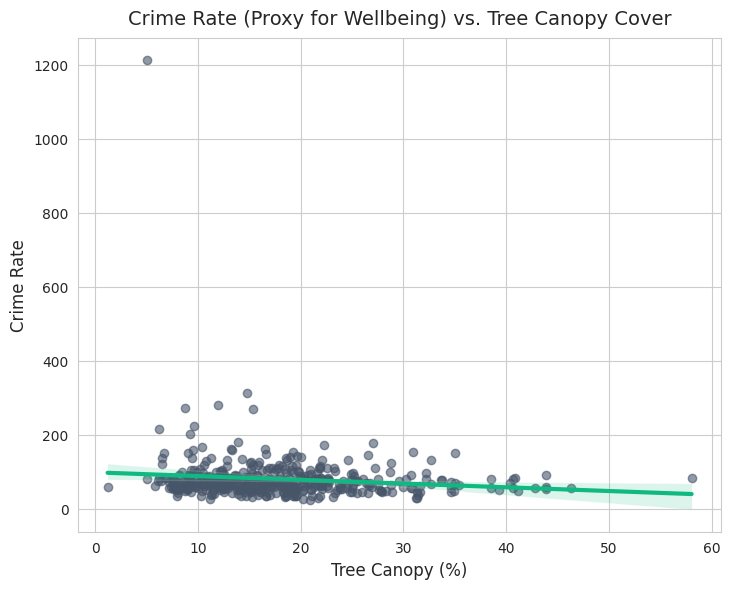


Generating Interactive Street Map...
✅ Map saved successfully.


In [4]:
# 1. INSTALL REQUIRED LIBRARIES (Run this in a separate cell first if you haven't)
# !pip install folium pandas matplotlib seaborn openpyxl xlrd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# ==========================================
# 2. LOAD AND PREP THE DATA
# ==========================================
print("Loading datasets from specific Excel sheets...")

# Explicitly target the 'Ward' sheet, ignoring the Metadata cover sheet
canopy_df = pd.read_excel('2024_tree_canopy_borough_ward_stats.xlsx', sheet_name='Ward')

# Explicitly target the 'Data' sheet, ignoring the 'Profiles' sheet
ward_data = pd.read_excel('ward-profiles-excel-version.xls', sheet_name='Data')

print("✅ Data loaded successfully. Cleaning ward names...")

# Clean Ward Names for Merging (Removing Borough prefixes like "Wandsworth - Balham")
ward_data['Ward name clean'] = ward_data['Ward name'].str.split(' - ').str[-1].str.strip()
canopy_df['Ward name clean'] = canopy_df['ward'].str.strip()

# Merge the datasets on the cleaned Ward Name
df_merged = pd.merge(canopy_df, ward_data, on='Ward name clean', how='inner')

# Find the exact column names using partial matches (this makes the code unbreakable against hidden spaces)
# 'Subjective well-being' column not found, using 'Crime rate - 2014/15' as a proxy for social cohesion/well-being.
wellbeing_col = 'Crime rate - 2014/15'
# 'Nitrogen Dioxide' column not found, commenting out related analysis for now.
# no2_col = [col for col in df_merged.columns if 'Nitrogen Dioxide' in col][0]

# Rename columns for the analysis
df_merged.rename(columns={
    'percentage': 'Canopy_Cover_Pct',
    wellbeing_col: 'Wellbeing_Score' # Renaming crime rate to Wellbeing_Score as a proxy
    # no2_col: 'NO2_Pollution' # Commented out as NO2 data is missing
}, inplace=True)

# Convert canopy from decimal to percentage (e.g., 0.20 to 20.0)
df_merged['Canopy_Cover_Pct'] = df_merged['Canopy_Cover_Pct'] * 100

# Convert Wellbeing_Score to numeric, coercing errors to NaN
df_merged['Wellbeing_Score'] = pd.to_numeric(df_merged['Wellbeing_Score'], errors='coerce')

# Drop rows with NaN in the relevant columns for plotting
df_merged.dropna(subset=['Canopy_Cover_Pct', 'Wellbeing_Score'], inplace=True)

print(f"✅ Merged data ready! Analyzing {len(df_merged)} wards.")


# ==========================================
# 3. ANALYSIS: COHESION & WELLBEING
# ==========================================
print("Generating Correlation Charts...")
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Subplot 1: Canopy vs Wellbeing (using Crime Rate as inverse proxy)
plt.subplot(1, 2, 1)
sns.regplot(x='Canopy_Cover_Pct', y='Wellbeing_Score', data=df_merged,
            scatter_kws={'alpha':0.6, 'color':'#475569'}, line_kws={'color':'#10B981', 'linewidth':3})
plt.title('Crime Rate (Proxy for Wellbeing) vs. Tree Canopy Cover', fontsize=14, pad=10)
plt.xlabel('Tree Canopy (%)', fontsize=12)
plt.ylabel('Crime Rate', fontsize=12)

# Subplot 2: Canopy vs Air Pollution (NO2) - Commented out as NO2 data is missing
# plt.subplot(1, 2, 2)
# sns.regplot(x='Canopy_Cover_Pct', y='NO2_Pollution', data=df_merged,
#             scatter_kws={'alpha':0.6, 'color':'#475569'}, line_kws={'color':'#EF4444', 'linewidth':3})
# plt.title('Air Pollution (NO2) vs. Tree Canopy Cover', fontsize=14, pad=10)
# plt.xlabel('Tree Canopy (%)', fontsize=12)
# plt.ylabel('NO2 Levels', fontsize=12)

plt.tight_layout()
plt.savefig('social_impact_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# 4. INTERACTIVE MAPPING: TOYNBEE STREET
# ==========================================
print("\nGenerating Interactive Street Map...")

# Toynbee Street Coordinates
toynbee_coords = [51.5173, -0.0743]

# Create Map
m = folium.Map(location=toynbee_coords, zoom_start=17, tiles='CartoDB positron')

# The Street Layer (Red line showing the intervention zone)
toynbee_street_path = [[51.5180, -0.0745], [51.5165, -0.0740]]
folium.PolyLine(
    locations=toynbee_street_path,
    color='#EF4444',
    weight=8,
    tooltip="Toynbee Street - Intervention Zone",
    opacity=0.7
).add_to(m)

# The Proposed Tree Pits (Green dots spaced 5m apart)
num_trees_to_show = 14
lats = np.linspace(toynbee_street_path[0][0], toynbee_street_path[1][0], num_trees_to_show)
lons = np.linspace(toynbee_street_path[0][1], toynbee_street_path[1][1], num_trees_to_show)

for i in range(num_trees_to_show):
    folium.CircleMarker(
        location=[lats[i], lons[i]],
        radius=6,
        color='#10B981',
        fill=True,
        fill_color='#10B981',
        fill_opacity=1.0,
        tooltip=f"Proposed Pit #{i+1} (Acer platanoides)"
    ).add_to(m)

# Save the map
m.save("Toynbee_Street_Map.html")
print("✅ Map saved successfully.")

# Display map in Colab
m